Navn: Milad Tootoonchi
# Minste Kvadraters Metode - AAPL stock data  
Datasettet består av historiske ukentlige AAPL-aksjepriser, inkludert dato, åpningskurs, høyeste- og laveste kurs,  
sluttkurs og volum (antall omsatte aksjer).  
Det historiske dataet vil ha dato fra 09. september 1984 til 17. november 2025.  
Dataen er hentet fra yahoo finance og problemstillingen er å undersøke om en lineær regresjonsmodell  
basert på minste-kvadraters metode kan brukes til å predikere kursens trend.

## Imports

In [74]:
using Downloads
using CSV
using DataFrames
using Dates
using Statistics
using Plots
using LinearAlgebra
using Random

# Laster ned CSV filen
url = "https://stooq.com/q/d/l/?s=aapl.us&i=w"
Downloads.download(url, "AAPL_weekly.csv")

"AAPL_weekly.csv"

## Load Data og Data-utforskning

In [75]:
df = CSV.read("AAPL_weekly.csv", DataFrame)

println(size(df))
first(df, 5)

(2151, 6)


Row,Date,Open,High,Low,Close,Volume
,Date,Float64,Float64,Float64,Float64,Int64
1,1984-09-09,0.0996047,0.100827,0.0984022,0.0996047,98811715
2,1984-09-16,0.0996047,0.107124,0.0972099,0.10472,954568288
3,1984-09-23,0.10744,0.108938,0.0996047,0.100827,667384362
4,1984-09-30,0.100827,0.102304,0.0923906,0.0941941,826115858
5,1984-10-07,0.0939084,0.0959978,0.0920853,0.0932972,664008250


In [76]:
# Konverter dato til riktig type og sorter
df.Date = Date.(df.Date)
sort!(df, :Date)

describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Any,Any,Int64,DataType
1,Date,,1984-09-09,2005-04-17,2025-11-23,0,Date
2,Open,29.9006,0.0556708,1.14325,270.42,0,Float64
3,High,30.7814,0.0568732,1.20222,277.32,0,Float64
4,Low,29.1844,0.0541729,1.1212,267.455,0,Float64
5,Close,30.0498,0.0547743,1.15103,272.41,0,Float64
6,Volume,1.85717e9,45018260,1.25146e9,13343150239,0,Int64


In [77]:
# Sjekker for NA-verdier
any(ismissing, eachrow(df))

false

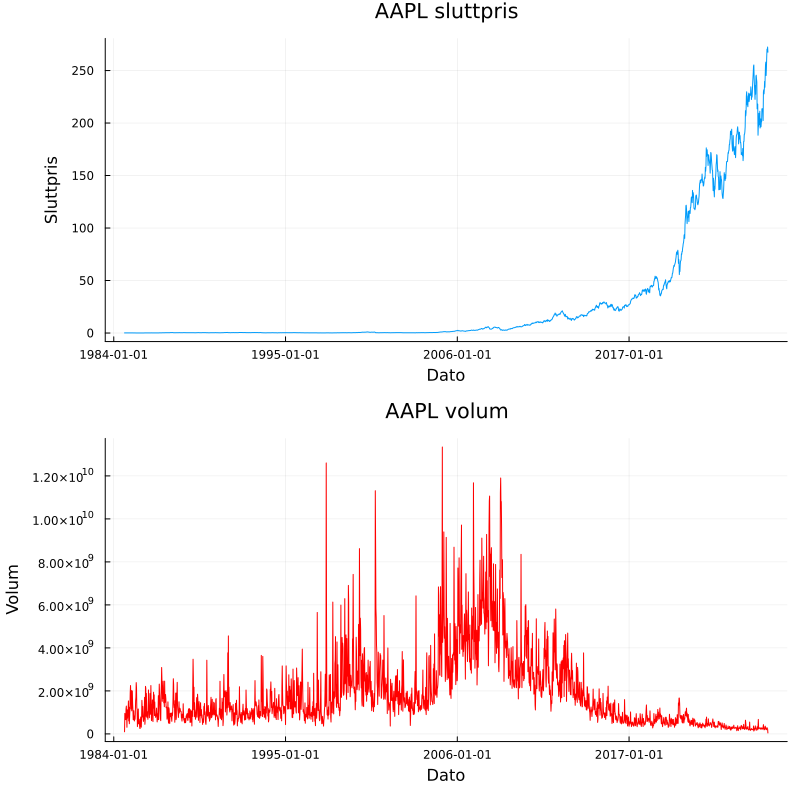

In [78]:
# Plotter sluttpris over tid
sluttpris = plot(df.Date, df.Close, title = "AAPL sluttpris", 
                xlabel = "Dato", ylabel = "Sluttpris", legend = false)

# Plotter volum
volum = plot(df.Date, df.Volume, title = "AAPL volum", 
            xlabel = "Dato", ylabel = "Volum", legend = false, color = :red)

plot(sluttpris, volum, layout = (2, 1), size = (800, 800))


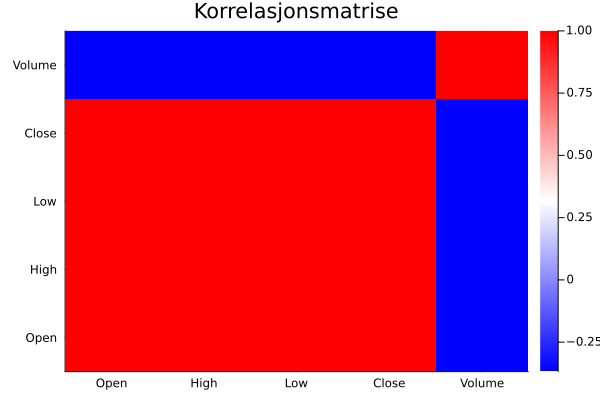

In [79]:
# Plotter Korrelasjonsmatrise
cols = [:Open, :High, :Low, :Close, :Volume]
df_corr = select(df, cols)
corr_matrix = cor(Matrix(df_corr))

heatmap(String.(cols), String.(cols), corr_matrix,
        title = "Korrelasjonsmatrise",
        color = :bwr
)

## Feature Engineering og mer Data-utforskning

SMA20, SMA50 og SMA200 vil bli regnet på og lagt til ettersom glidende gjennomsnitt jevner ut støy og gjør det enklere for modellen å fange opp kortsiktige, mellomlange og langsiktige trender i aksjeprisen.

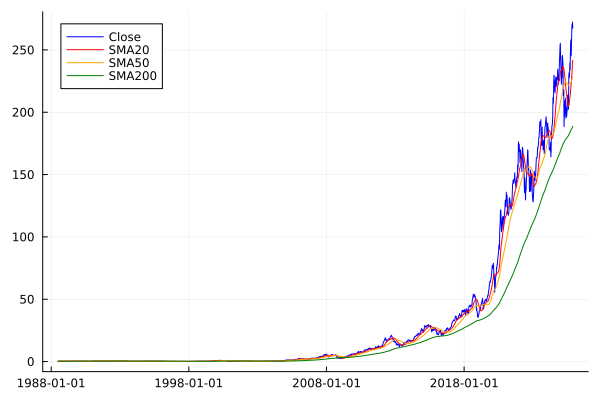

In [80]:
# Simple moving average
sma(x, n) = [i < n ? missing : mean(x[i-n+1:i]) for i in 1:length(x)]

df.SMA20  = sma(df.Close, 20)
df.SMA50  = sma(df.Close, 50)
df.SMA200 = sma(df.Close, 200)

# De første 1999 radene får NA-verdier ettersom de mangler nok datapunkter
df = dropmissing(df)

plot(df.Date, df.Close, label = "Close", color=:blue)
plot!(df.Date, df.SMA20, label = "SMA20", color=:red)
plot!(df.Date, df.SMA50, label = "SMA50", color=:orange)
plot!(df.Date, df.SMA200, label = "SMA200", color=:green)

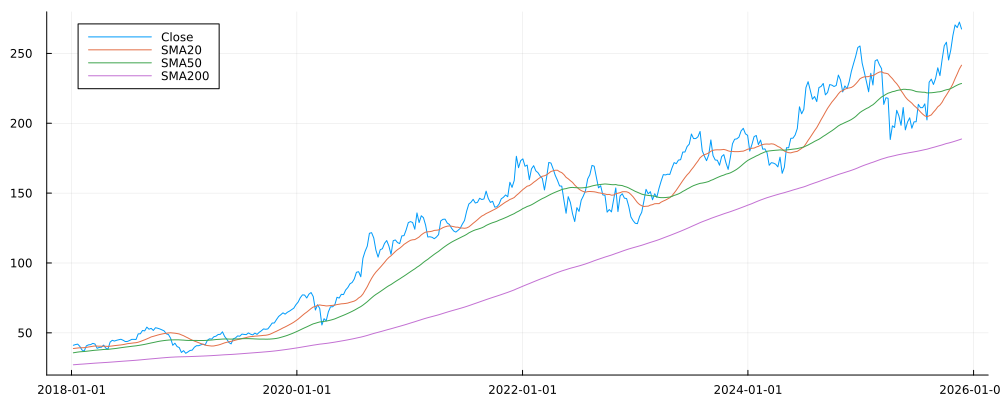

In [81]:
# Nærmere utforsking når prisene stiger kraftig
df_2018 = df[df.Date .>= Date(2018, 1, 1), :]

plot(df_2018.Date, df_2018.Close, label = "Close")
plot!(df_2018.Date, df_2018.SMA20, label = "SMA20")
plot!(df_2018.Date, df_2018.SMA50, label = "SMA50")
plot!(df_2018.Date, df_2018.SMA200, label = "SMA200")
plot!(size = (1000, 400))

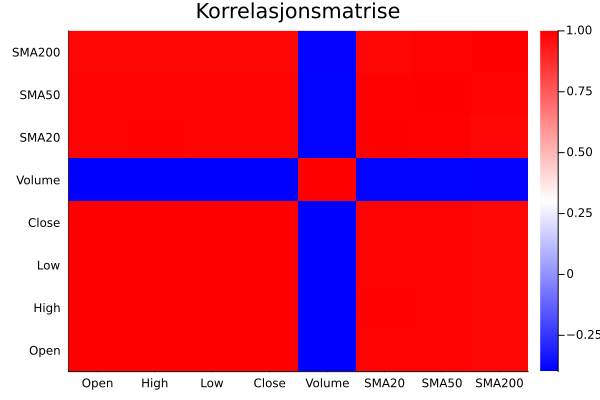

In [82]:
# Plotter ny Korrelasjonsmatrise med nye verdier
cols = [:Open, :High, :Low, :Close, :Volume, :SMA20, :SMA50, :SMA200]
df_corr = select(df, cols)
corr_matrix = cor(Matrix(df_corr))

heatmap(String.(cols), String.(cols), corr_matrix,
        title = "Korrelasjonsmatrise",
        color = :bwr
)

## Trening

### Deler datasettet i trenings- og testdata

In [83]:
Y = df.Close
X = select(df, [:Open, :High, :Low, :Volume, :SMA20, :SMA50, :SMA200])
X = hcat(ones(nrow(df)), X)     # inkluderer bias

# Splitter 70 / 30
n = nrow(df)
split_index = Int(round(n * 0.7))

X_train = X[1:split_index, :]
y_train = Y[1:split_index]
X_test = X[split_index+1:end, :]
y_test = Y[split_index+1:end]

X_train = Matrix(X_train)
y_train = Vector(y_train)
X_test  = Matrix(X_test)
y_test  = Vector(y_test)

# sjekker fordelingen
println(size(X_train)," ", size(X_test))

(1366, 8) (586, 8)


### Minste-Kvadraters Metode

Test MSE = 3.4742664822998597


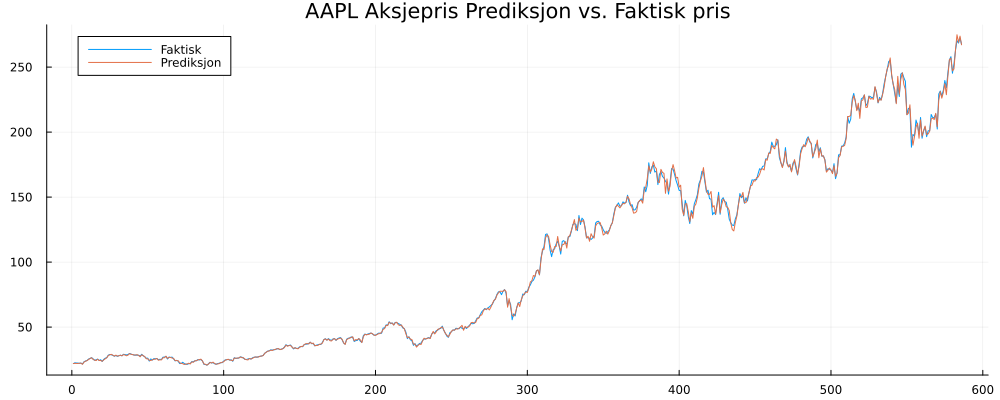

In [84]:
function minste_kvadrater(X, y)
    β = (X'X) \ (X' * y)
    return β
end

β_hat = minste_kvadrater(X_train, y_train)

# Prediksjon
y_hat = X_test * β_hat

# MSE 
mse = mean((y_hat .- y_test).^2)
println("Test MSE = $mse")

# Plot faktisk vs. predikert
plot(y_test, label = "Faktisk")
plot!(y_hat, label = "Prediksjon", title = "AAPL Aksjepris Prediksjon vs. Faktisk pris")
plot!(size = (1000, 400))

### R^2 - visualisering

R^2 = 0.999353075884667


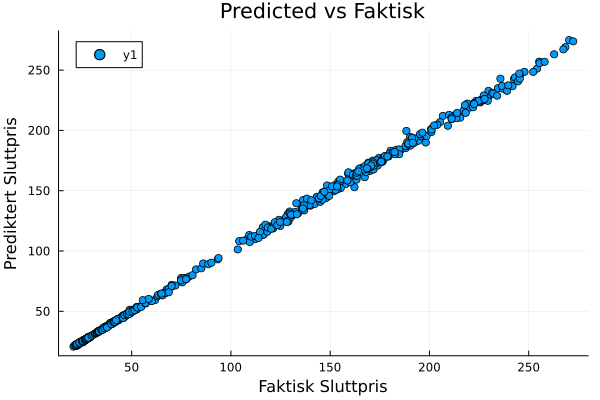

In [85]:
ss_res = sum((y_test .- y_hat).^2)
ss_tot = sum((y_test .- mean(y_test)).^2)
R2 = 1 - ss_res/ss_tot
println("R^2 = $R2")

scatter(y_test, y_hat,
        xlabel = "Faktisk Sluttpris",
        ylabel = "Prediktert Sluttpris",
        title = "Predicted vs Faktisk")

Punktene samler seg til noe som ligner en linje, dette betyr at prediksjonen er fine

### Residualplot

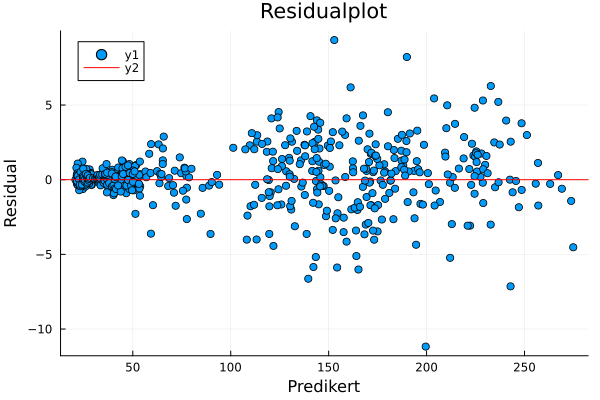

In [86]:
residuals = y_test .- y_hat

scatter(y_hat, residuals,
        xlabel = "Predikert",
        ylabel = "Residual",
        title = "Residualplot")

hline!([0], color = :red)

Residualplottet over viser at modellen gjør større feil når akseprisene stiger, men modellen predikerer stort sett uten systematisk bias

## Trening med Regularisering
using ridge regression

Test MSE = 58.45053647750602


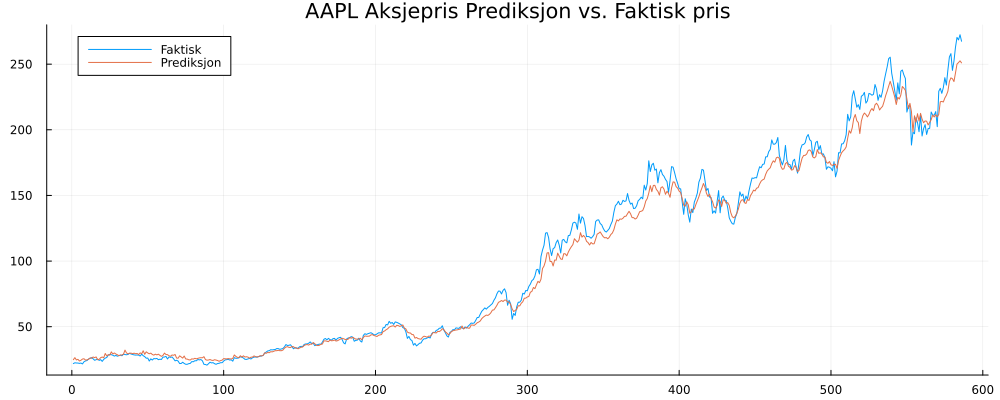

In [87]:
# wRidge funksjonen brukt fra project 2

function wRidge(X, y, λ)
    n, p = size(X)

    # Compute Gram (kernel) matrix
    K = X * X'

    # Solve for α in (K + λI)α = y
    α = (K + λ * I(n)) \ y

    # Compute θ = X'α
    θ = X' * α

    return θ 
end

# Predikasjon med ridge regression
λ = 10.0    # velger en regulasjons stykre
θ = wRidge(X_train, y_train, λ)

y_pred = X_test * θ

# MSE 
mse = mean((y_pred .- y_test).^2)
println("Test MSE = $mse")

# Plot faktisk vs. predikert
plot(y_test, label = "Faktisk")
plot!(y_pred, label = "Prediksjon", title = "AAPL Aksjepris Prediksjon vs. Faktisk pris")
plot!(size = (1000, 400))

### R^2 visualisering (Ridge)

R^2 (ridge) = 0.9891162460352158


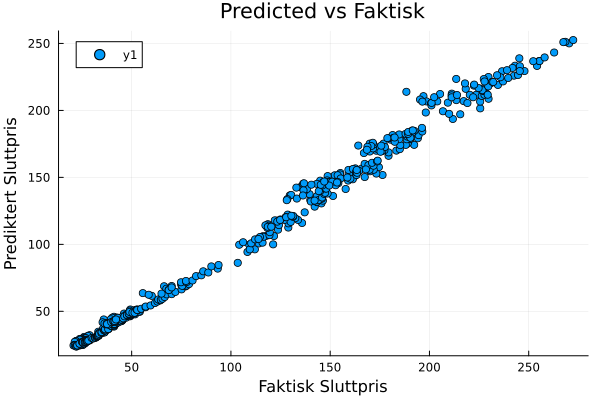

In [88]:
ss_res = sum((y_test .- y_pred).^2)
ss_tot = sum((y_test .- mean(y_test)).^2)
r2_ridge = 1 - ss_res / ss_tot
println("R^2 (ridge) = ", r2_ridge)

scatter(y_test, y_pred,
        xlabel = "Faktisk Sluttpris",
        ylabel = "Prediktert Sluttpris",
        title = "Predicted vs Faktisk")

### Residualplotting (Ridge)

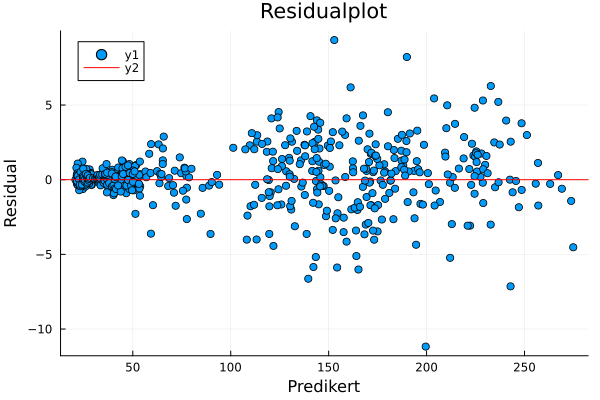

In [89]:
residuals = y_test .- y_hat

scatter(y_hat, residuals,
        xlabel = "Predikert",
        ylabel = "Residual",
        title = "Residualplot")

hline!([0], color = :red)

## Konklusjon
I dette prosjektet har jeg brukt historiske data for AAPL-aksjen til å bygge en lineær regresjonsmodell basert på minste kvadraters metode. Resultatene viser at den vanlige lineære modellen gir svært god ytelse, noe som kommer fram gjennom en lav test MSE på omtrent 3.47 og en R²-verdi på 0.9993. Dette betyr at modellen forklarer nesten all variasjonen i sluttprisen, noe som er forventet når datasettet inneholder tydelige trender og glidende gjennomsnitt som forklaringsvariabler.

Jeg testet også en ridge-regresjon med λ = 10.0 for å se om regularisering kunne forbedre resultatene. Ridge-modellen ga en høyere test MSE på omtrent 58.45 og en lavere R²-verdi på 0.9891. Selv om dette fortsatt er gode resultater, viser det at ridge-regresjon ikke gir noen fordel i dette tilfellet. Dette kan skyldes at datasettet allerede er ganske stabilt og ikke har store problemer med overtilpasning, og dermed passer vanlig minste kvadraters metode bedre.